In [1]:
!pip install librosa seaborn scikit-learn

In [2]:
!wget https://zenodo.org/records/3384388/files/6_dB_valve.zip
!unzip 6_dB_valve.zip

--2026-04-12 06:25:56--  https://zenodo.org/records/3384388/files/6_dB_valve.zip
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.52.235, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6915951837 (6.4G) [application/octet-stream]
Saving to: ‘6_dB_valve.zip’

6_dB_valve.zip      100%[===================>]   6.44G  29.0MB/s    in 3m 57s  

2026-04-12 06:29:53 (27.8 MB/s) - ‘6_dB_valve.zip’ saved [6915951837/6915951837]

Archive:  6_dB_valve.zip
   creating: valve/
   creating: valve/id_00/
   creating: valve/id_00/abnormal/
  inflating: valve/id_00/abnormal/00000000.wav  
  inflating: valve/id_00/abnormal/00000001.wav  
  inflating: valve/id_00/abnormal/00000002.wav  
  inflating: valve/id_00/abnormal/00000003.wav  
  inflating: valve/id_00/abnormal/00000004.wav  
  inflating: valve/id_00/abnormal/00000005.wav  
  inflating: valve/id_00/abnormal/00000006.wav  
  inflating: val

In [3]:
import os

print(os.listdir())

['.config', '6_dB_valve.zip', 'valve', 'sample_data']


In [6]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [7]:
DATA_PATH = "/content/valve"

In [9]:
import os
import librosa

DATA_PATH = "/content/valve"

signals = []
labels = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".wav"):   # only audio files
            file_path = os.path.join(root, file)

            try:
                signal, sr = librosa.load(file_path, sr=None)
                signals.append(signal)

                # label = folder name (important)
                label = root.split("/")[-1]
                labels.append(label)

            except Exception as e:
                print("Error loading:", file_path)

print("Total samples:", len(signals))
print("Classes:", set(labels))

Total samples: 4170
Classes: {'normal', 'abnormal'}


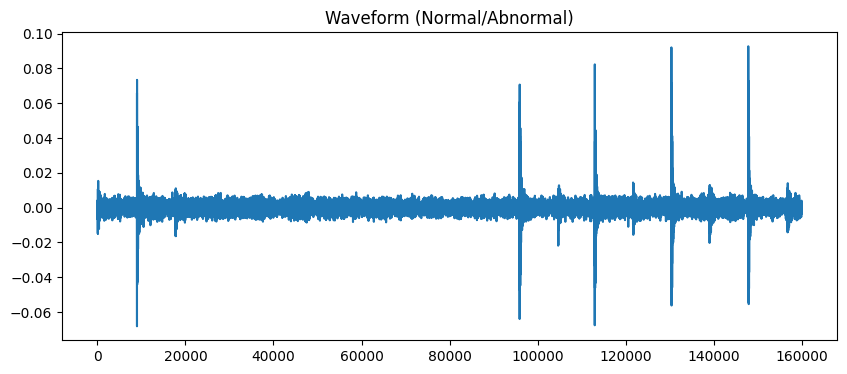

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(signals[0])
plt.title("Waveform (Normal/Abnormal)")
plt.show()

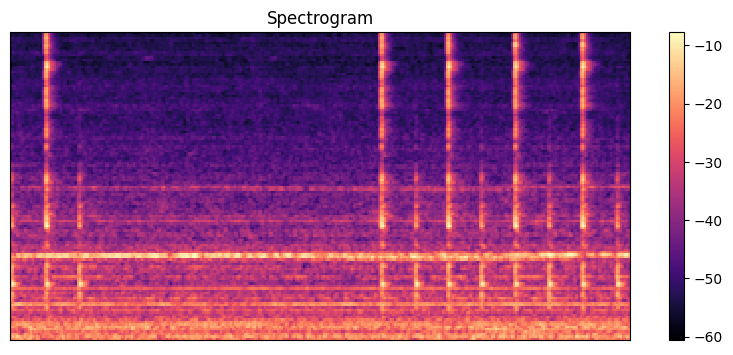

In [11]:
import librosa.display

S = librosa.feature.melspectrogram(y=signals[0], sr=sr)

plt.figure(figsize=(10,4))
librosa.display.specshow(librosa.power_to_db(S), sr=sr)
plt.colorbar()
plt.title("Spectrogram")
plt.show()

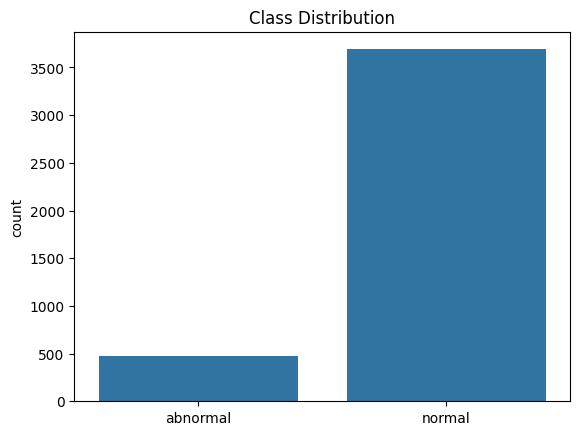

In [12]:
import seaborn as sns

sns.countplot(x=labels)
plt.title("Class Distribution")
plt.show()

In [13]:
import numpy as np

def extract_features(signal, sr):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    return np.mean(mfcc.T, axis=0)

features = []

for signal in signals:
    features.append(extract_features(signal, sr))

features = np.array(features)

print(features.shape)

(4170, 13)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8908872901678657
              precision    recall  f1-score   support

    abnormal       1.00      0.03      0.06        94
      normal       0.89      1.00      0.94       740

    accuracy                           0.89       834
   macro avg       0.95      0.52      0.50       834
weighted avg       0.90      0.89      0.84       834



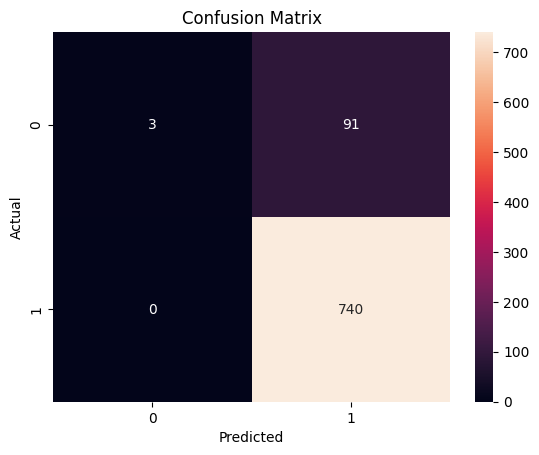

In [17]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
def add_noise(signal):
    noise = np.random.randn(len(signal))
    return signal + 0.005 * noise

aug_signals = [add_noise(s) for s in signals]

In [19]:
aug_features = []

for signal in aug_signals:
    aug_features.append(extract_features(signal, sr))

aug_features = np.array(aug_features)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    aug_features, labels, test_size=0.2
)

model.fit(X_train2, y_train2)

y_pred2 = model.predict(X_test2)

print("New Accuracy:", accuracy_score(y_test2, y_pred2))

New Accuracy: 0.9088729016786571


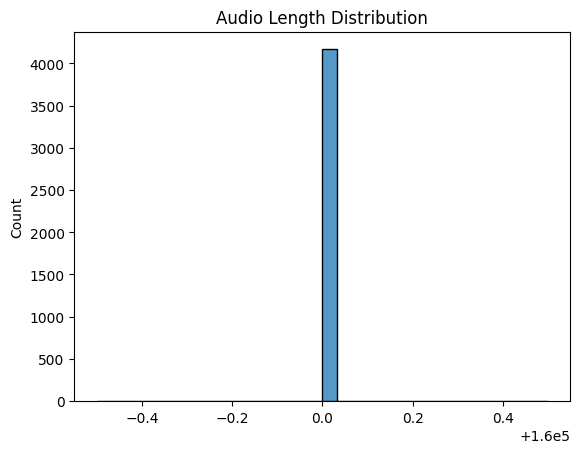

In [20]:
lengths = [len(s) for s in signals]

sns.histplot(lengths, bins=30)
plt.title("Audio Length Distribution")
plt.show()

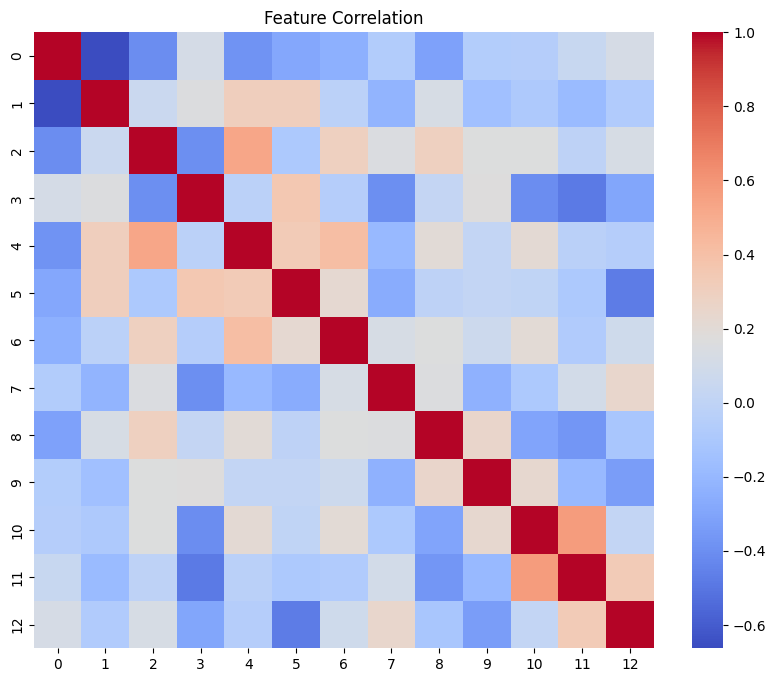

In [21]:
import pandas as pd

df = pd.DataFrame(features)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [22]:
!pip install tensorflow

In [23]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

In [24]:
DATA_PATH = "/content/valve"

X = []
y = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            signal, sr = librosa.load(file_path, sr=None)

            # Create Mel Spectrogram
            spec = librosa.feature.melspectrogram(y=signal, sr=sr)
            spec_db = librosa.power_to_db(spec)

            # Resize to fixed shape
            spec_db = np.resize(spec_db, (128, 128))

            X.append(spec_db)

            label = root.split("/")[-1]
            y.append(0 if label == "normal" else 1)

X = np.array(X)
y = np.array(y)

print("Shape:", X.shape)

Shape: (4170, 128, 128)


In [25]:
X = X / np.max(X)

# Add channel dimension for CNN
X = X.reshape(X.shape[0], 128, 128, 1)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
model = models.Sequential()

# Conv Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)))
model.add(layers.MaxPooling2D((2,2)))

# Conv Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Conv Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 79s 757ms/step - accuracy: 0.9913 - loss: 0.0263 - val_accuracy: 0.9844 - val_loss: 0.0436
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 67s 643ms/step - accuracy: 0.9958 - loss: 0.0180 - val_accuracy: 0.9916 - val_loss: 0.0188
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 70s 671ms/step - accuracy: 0.9970 - loss: 0.0093 - val_accuracy: 0.9928 - val_loss: 0.0188
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 84s 690ms/step - accuracy: 0.9985 - loss: 0.0073 - val_accuracy: 0.9916 - val_loss: 0.0331
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 82s 780ms/step - accuracy: 0.9991 - loss: 0.0061 - val_accuracy: 0.9916 - val_loss: 0.0218


In [32]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 315ms/step - accuracy: 0.9916 - loss: 0.0218
Test Accuracy: 0.9916067123413086


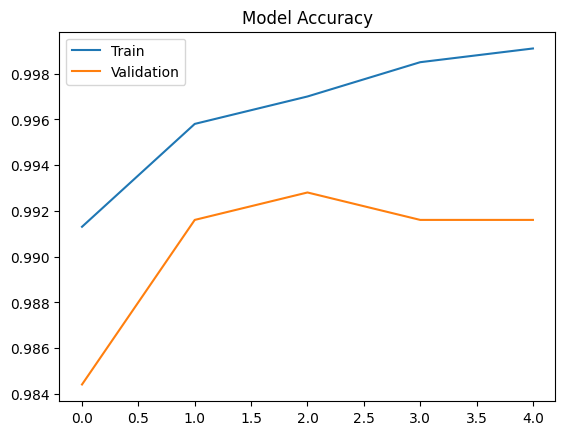

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

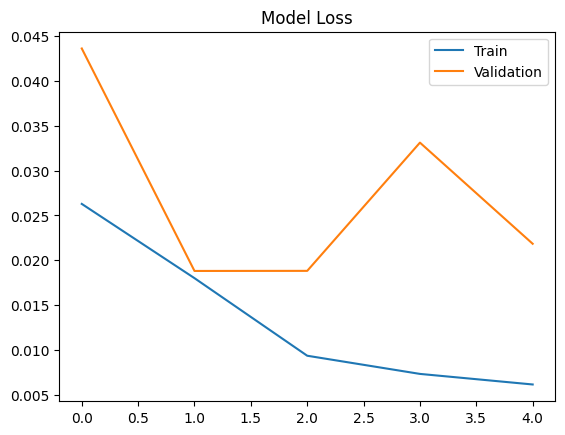

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train", "Validation"])
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step


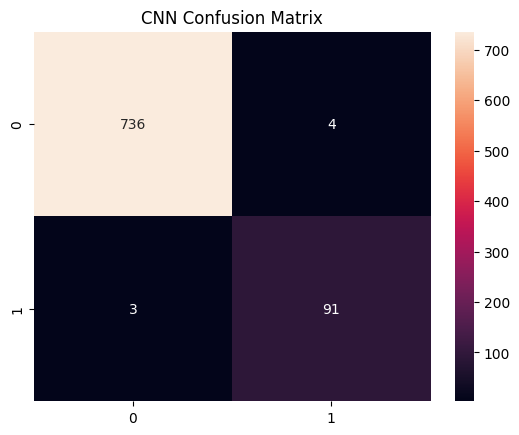

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.show()